In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shrutimechlearn/churn-modelling/Churn_Modelling.csv


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [5]:
df=pd.read_csv('/kaggle/input/datasets/shrutimechlearn/churn-modelling/Churn_Modelling.csv')

In [6]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2662,2663,15742272,Ozerova,669,France,Female,44,8,96418.09,1,0,0,131609.48,1
8647,8648,15593241,Tochukwu,444,France,Male,43,3,0.00,2,1,1,159131.21,0
2128,2129,15605835,Rice,743,France,Male,37,8,69143.91,2,0,1,105780.18,0
6376,6377,15640686,Greco,700,France,Male,46,5,95872.86,1,1,0,98273.01,1
6430,6431,15728012,Everett,678,Spain,Female,40,3,128398.38,1,1,0,168658.30,0
8048,8049,15595713,Heller,548,Spain,Male,33,6,0.00,1,1,1,31728.35,0
3753,3754,15578211,Connolly,777,France,Male,23,6,0.00,2,1,1,163225.48,0
1453,1454,15714227,Kelly,672,France,Female,53,7,0.00,1,1,1,136910.18,0
3443,3444,15606755,Moretti,597,Spain,Female,46,4,0.00,2,1,0,58667.16,1
5954,5955,15811947,Gordon,850,France,Male,33,0,124781.67,1,0,1,33700.52,0


In [7]:
df.shape

(10000, 14)

In [8]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [9]:
df.sample(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
437,516,France,Male,35,10,104088.59,2,0,0,119666.00,0
9127,630,Spain,Male,39,10,105473.74,1,0,0,58854.88,1
2159,683,France,Male,72,3,140997.26,1,0,1,52876.41,0
1573,668,France,Female,35,6,102482.76,1,1,1,53994.64,0
5852,544,Spain,Male,22,3,66483.32,1,0,1,110317.39,0
841,818,France,Female,31,1,186796.37,1,0,0,178252.63,0
4614,730,France,Male,34,1,0.00,2,1,1,126592.01,0
4395,660,France,Female,20,6,167685.56,1,1,0,57929.90,0
6716,515,Spain,Male,29,4,151012.55,2,1,0,9770.97,0
6670,758,Spain,Female,43,10,0.00,2,1,1,55313.44,0


In [10]:
df['Geography'].value_counts() 

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [11]:
df['Exited'].value_counts()
# case of dataset imbalace

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

In [14]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [15]:
X=df.drop(columns='Exited')
y=df.Exited

In [16]:
X.shape, y.shape

((10000, 11), (10000,))

In [17]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train.shape, X_test.shape

((8000, 11), (2000, 11))

In [19]:
std=StandardScaler()
new_train=std.fit_transform(X_train)
new_test=std.transform(X_test)
X_train=pd.DataFrame(new_train, columns=X_train.columns)
X_test=pd.DataFrame(new_test, columns=X_test.columns)

In [29]:
X_train.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
1147,0.325367,0.960446,0.692704,0.523487,0.808436,-1.540351,-1.025834,0.701237,1.725723,-0.576388,-1.094993
3346,-1.044494,1.435808,-0.001345,0.430566,-0.916688,0.649203,-1.025834,1.325714,1.725723,-0.576388,0.913248
6038,0.148945,0.675228,-0.001345,0.764862,-0.916688,0.649203,0.974817,1.345950,-0.579467,-0.576388,0.913248
4329,-1.687913,1.150590,-0.695393,-1.218471,0.808436,-1.540351,0.974817,1.280824,-0.579467,-0.576388,-1.094993
4031,0.875386,-0.941003,1.386753,-1.218471,0.808436,-1.540351,-1.025834,1.316543,-0.579467,-0.576388,-1.094993


In [21]:
X_test.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
1205,0.180078,0.580156,-1.389442,0.766088,-0.916688,-1.540351,-1.025834,0.181695,1.725723,-0.576388,0.913248
1442,-0.473719,0.104794,-0.001345,-1.218471,0.808436,0.649203,0.974817,-0.513463,-0.579467,-0.576388,0.913248
1504,-0.587874,0.199866,1.386753,1.190593,0.808436,-1.540351,0.974817,-0.328311,1.725723,-0.576388,-1.094993
1160,-1.418092,-0.370569,1.733777,1.603850,-0.916688,-1.540351,0.974817,0.362451,-0.579467,1.734942,0.913248
538,-0.764295,-0.085351,0.692704,0.098582,-0.916688,0.649203,-1.025834,-1.589738,-0.579467,-0.576388,0.913248


In [22]:
lr=LogisticRegression(penalty='l2')

In [23]:
lr.fit(X_train, y_train)

LogisticRegression()

In [24]:
y_pred_train=lr.predict(X_train)
print('-'*15, "Training Results", '-'*15)
print("Accuracy: ", accuracy_score(y_train, y_pred_train))
print("preciosion: ", precision_score(y_train, y_pred_train))
print("Recall: ", precision_score(y_train, y_pred_train))

--------------- Training Results ---------------
Accuracy:  0.811375
preciosion:  0.6157804459691252
Recall:  0.6157804459691252


In [25]:
y_pred=lr.predict(X_test)
print('-'*15, "Test Results", '-'*15)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("preciosion: ", precision_score(y_test, y_pred))
print("Recall: ", precision_score(y_test, y_pred))

--------------- Test Results ---------------
Accuracy:  0.811
preciosion:  0.5524475524475524
Recall:  0.5524475524475524


In [26]:
# Lets see if ANN works better

In [27]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [79]:
model=Sequential()
model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [83]:
history=model.fit(X_train, y_train,epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6131 - loss: 0.6638 - val_accuracy: 0.7994 - val_loss: 0.5200
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7937 - loss: 0.4823 - val_accuracy: 0.8075 - val_loss: 0.4478
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8125 - loss: 0.4441 - val_accuracy: 0.8275 - val_loss: 0.4265
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8197 - loss: 0.4312 - val_accuracy: 0.8331 - val_loss: 0.4204
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8247 - loss: 0.4243 - val_accuracy: 0.8331 - val_loss: 0.4173
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8277 - loss: 0.4192 - val_accuracy: 0.8381 - val_loss: 0.4115
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8292 - loss: 0.4126 - val_accuracy: 0.8350 - val_loss: 0.4079
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8336 - loss: 0.4066 - val_accu

In [84]:
y_pred_log=model.predict(X_train)
y_pred_train=np.where(y_pred_log>0.5, 1, 0)
print('-'*15, "Training Results", '-'*15)
print("Accuracy: ", accuracy_score(y_train, y_pred_train))
print("preciosion: ", precision_score(y_train, y_pred_train))
print("Recall: ", precision_score(y_train, y_pred_train))

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step
--------------- Training Results ---------------
Accuracy:  0.8665
preciosion:  0.788
Recall:  0.788


In [85]:
y_pred_log=model.predict(X_test)
y_pred=np.where(y_pred_log>0.5, 1, 0)
print('-'*15, "Test Results", '-'*15)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("preciosion: ", precision_score(y_test, y_pred))
print("Recall: ", precision_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
--------------- Test Results ---------------
Accuracy:  0.8535
preciosion:  0.7155172413793104
Recall:  0.7155172413793104


In [86]:
train_acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

train_loss=history.history['loss']
val_loss=history.history['val_loss']

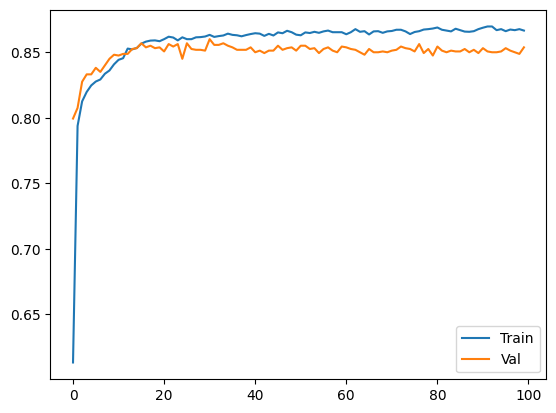

In [87]:
plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Val")
plt.legend()
plt.show()

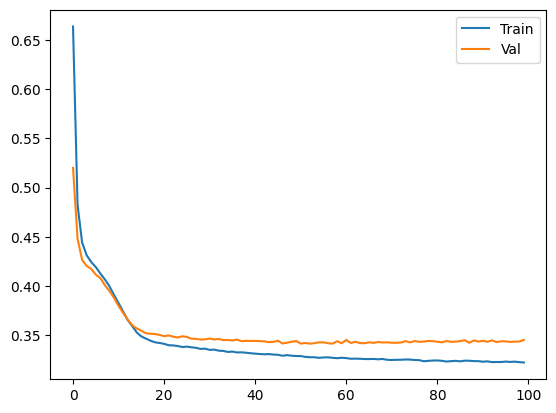

In [88]:
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Val")
plt.legend()
plt.show()